In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

In [8]:

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
df=pd.read_csv('/content/project dataset.csv')

In [10]:
df

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...
...,...,...
8670,ISFP,'https://www.youtube.com/watch?v=t8edHB_h908||...
8671,ENFP,'So...if this thread already exists someplace ...
8672,INTP,'So many questions when i do these things. I ...
8673,INFP,'I am very conflicted right now when it comes ...


In [11]:
df.shape

(8675, 2)

In [12]:
df.isnull().sum()

,0
type,0
posts,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.sample(6)

,type,posts
5076,ENTP,'I'm sure someone has been under the effects o...
7485,INFP,'I hate these mind games. I think when somebod...
1418,ENTP,'lol for some reason I think you would have go...
3060,INFJ,'May I pop in? I've been struggling with perf...
7072,ENTP,'https://www.youtube.com/watch?v=mFarooYLvgE||...
403,ISFP,'Warm Spring - Soft Autumn overlap. My hair ...


##Total Personalities Types

In [15]:
df["type"].nunique()

16

<Axes: xlabel='type'>

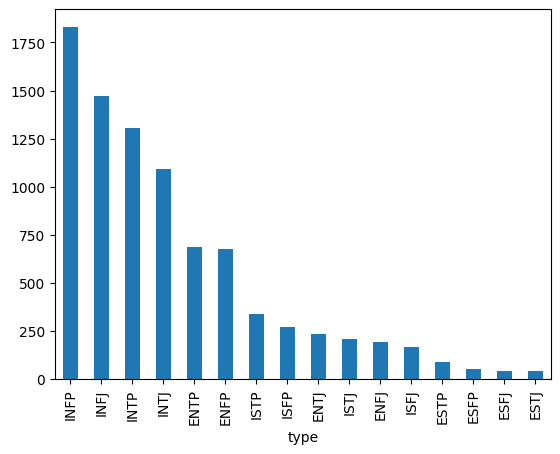

In [16]:
df["type"].value_counts().plot(kind="bar")

##Text Processing

In [17]:
X=df[["posts"]]
y=df[["type"]]

In [18]:
X["posts"]=X["posts"].str.lower()

/tmp/ipykernel_28764/2562796039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["posts"]=X["posts"].str.lower()


In [19]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [20]:
X["posts"]=X["posts"].apply(remove_punctuation)

/tmp/ipykernel_28764/2915011185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["posts"]=X["posts"].apply(remove_punctuation)


In [21]:
X

,posts
0,httpwwwyoutubecomwatchvqsxhcwe3krwhttp41mediat...
1,im finding the lack of me in these posts very ...
2,good one httpswwwyoutubecomwatchvfhigbolff...
3,dear intp i enjoyed our conversation the oth...
4,youre firedthats another silly misconception t...
...,...
8670,httpswwwyoutubecomwatchvt8edhbh908ixfp just be...
8671,soif this thread already exists someplace else...
8672,so many questions when i do these things i wo...
8673,i am very conflicted right now when it comes t...


In [22]:
def remove_extra_spaces(text):
    return " ".join(text.split())

In [23]:
X["posts"]=X["posts"].apply(remove_extra_spaces)

/tmp/ipykernel_28764/2315593377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["posts"]=X["posts"].apply(remove_extra_spaces)


In [24]:
def remove_links(text):

    # remove http, https and www links
    text = re.sub(r'http\S+|https\S+|www\S+', '', text)

    return text

In [25]:
X["posts"]=X["posts"].apply(remove_links)

/tmp/ipykernel_28764/3100069131.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["posts"]=X["posts"].apply(remove_links)


In [26]:
X

,posts
0,and intj moments sportscenter not top ten pl...
1,im finding the lack of me in these posts very ...
2,good one course to which i say i know thats m...
3,dear intp i enjoyed our conversation the other...
4,youre firedthats another silly misconception t...
...,...
8670,just because i always think of cats as fi dom...
8671,soif this thread already exists someplace else...
8672,so many questions when i do these things i wou...
8673,i am very conflicted right now when it comes t...


In [27]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [28]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [29]:
X["posts"]=X["posts"].apply(clean_text)

/tmp/ipykernel_28764/161630459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["posts"]=X["posts"].apply(clean_text)


In [30]:
tf=TfidfVectorizer(max_features=5000)
X=tf.fit_transform(X["posts"])

In [31]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.metrics import accuracy_score

In [34]:
model=LinearSVC(C=0.1)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(accuracy_score(y_test,y_pred))


0.6455331412103746


In [43]:
pred_labels = le.inverse_transform(y_pred)
actual_labels = le.inverse_transform(y_test)
print("Predicted Labels:", pred_labels)
print("Actual Labels:", actual_labels)

Predicted Labels: ['INTP' 'INFJ' 'INTP' ... 'INFP' 'INTP' 'INTP']
Actual Labels: ['INTP' 'INTJ' 'INTP' ... 'INFJ' 'ISTJ' 'INTP']


##Logistic Regression GridSearch

In [39]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000,C= 1,penalty='l2',solver='lbfgs')
lr.fit(X_train,y_train)
y_l=lr.predict(X_test)
print(accuracy_score(y_test,y_l))

0.6299711815561959


In [41]:
pred_labels = le.inverse_transform(y_l)
actual_labels = le.inverse_transform(y_test)
print("Predicted Labels:", pred_labels)
print("Actual Labels:", actual_labels)

Predicted Labels: ['INTP' 'INFJ' 'INTP' ... 'INFP' 'INTP' 'INTP']
Actual Labels: ['INTP' 'INTJ' 'INTP' ... 'INFJ' 'ISTJ' 'INTP']


## Model Evaluation: Classification Reports and Comparison

In [53]:
from sklearn.metrics import classification_report

class_names = le.classes_

print("\n--- Classification Report for LinearSVC Model ---")
report_svm = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_test, y_pred, target_names=class_names))

print("\n--- Classification Report for Logistic Regression Model ---")
report_lr = classification_report(y_test, y_l, target_names=class_names, output_dict=True)
print(classification_report(y_test, y_l, target_names=class_names))


--- Classification Report for LinearSVC Model ---
              precision    recall  f1-score   support

        ENFJ       0.56      0.12      0.20        41
        ENFP       0.68      0.57      0.62       125
        ENTJ       0.75      0.34      0.47        44
        ENTP       0.62      0.52      0.56       135
        ESFJ       1.00      0.14      0.25         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       1.00      0.20      0.33        15
        INFJ       0.67      0.67      0.67       288
        INFP       0.61      0.87      0.72       370
        INTJ       0.61      0.72      0.66       193
        INTP       0.68      0.80      0.73       293
        ISFJ       0.94      0.33      0.49        45
        ISFP       0.61      0.21      0.31        53
        ISTJ       0.71      0.27      0.39        44
        ISTP       0.68      0.45      0.54        67

    accuracy                 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### Visual Comparison of Metrics

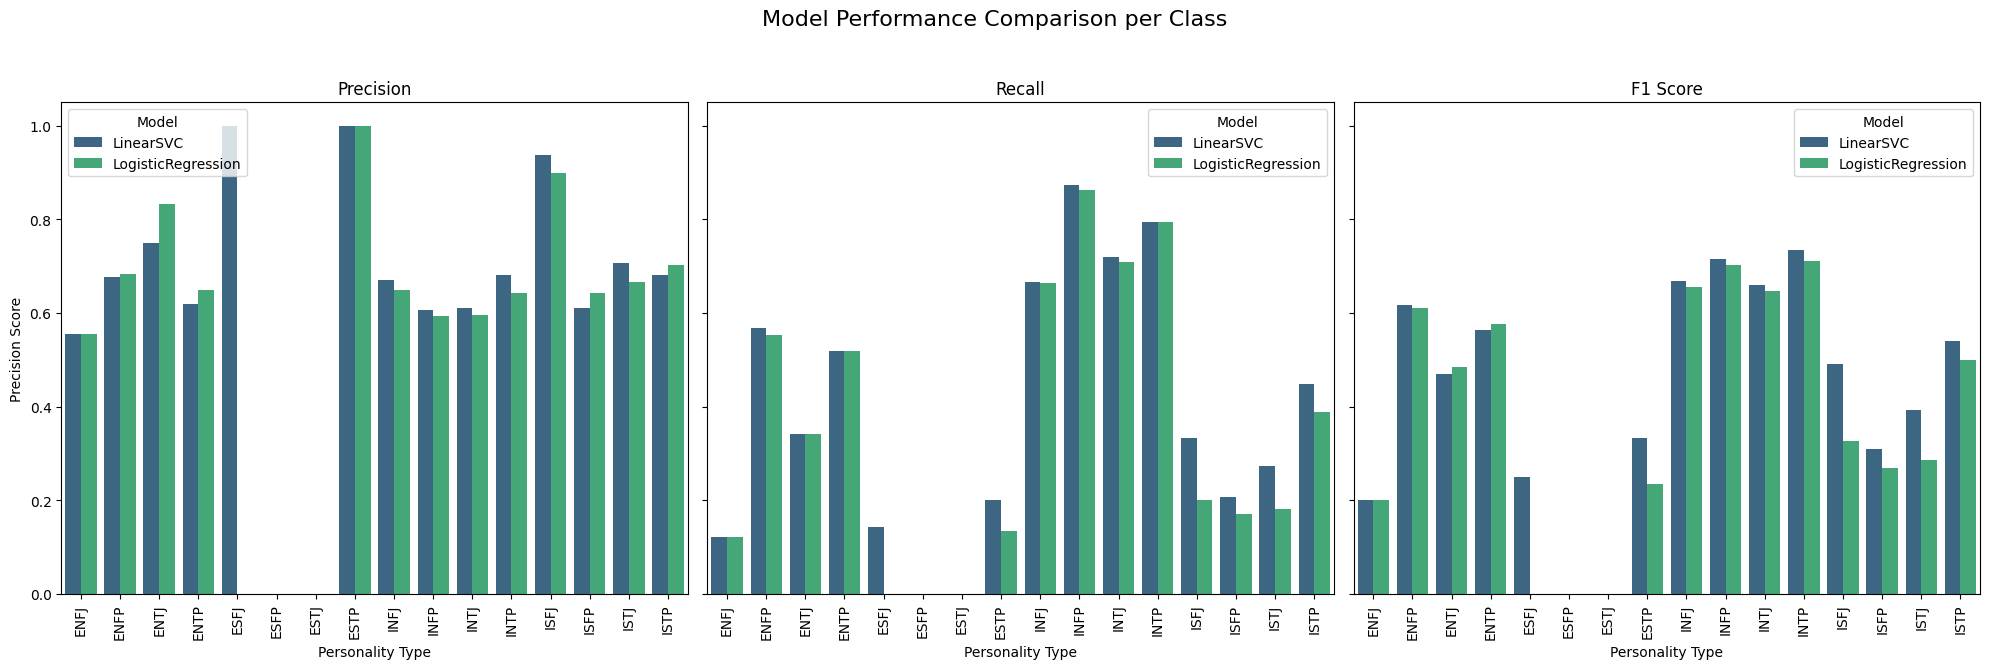

In [54]:
df_svm = pd.DataFrame(report_svm).transpose()
df_lr = pd.DataFrame(report_lr).transpose()

df_svm_plot = df_svm.drop(index=['accuracy', 'macro avg', 'weighted avg'])
df_lr_plot = df_lr.drop(index=['accuracy', 'macro avg', 'weighted avg'])

df_svm_plot['model'] = 'LinearSVC'
df_lr_plot['model'] = 'LogisticRegression'

combined_df = pd.concat([df_svm_plot, df_lr_plot])
combined_df = combined_df.reset_index().rename(columns={'index': 'class'})

melted_df = combined_df.melt(id_vars=['class', 'model'], value_vars=['precision', 'recall', 'f1-score'], var_name='metric', value_name='score')

metrics_to_plot = ['precision', 'recall', 'f1-score']
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle('Model Performance Comparison per Class', fontsize=16)

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='class', y='score', hue='model', data=melted_df[melted_df['metric'] == metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric.replace("-", " ").title()}')
    axes[i].set_xlabel('Personality Type')
    axes[i].set_ylabel(f'{metric.title()} Score')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend(title='Model')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Hyperparameter Tuning with GridSearchCV for LinearSVC

In [55]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for LinearSVC
param_grid_svc = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'dual': [False] # Set dual to False when n_samples > n_features, or when loss='hinge' is used with L1 penalty.
}

# Create a GridSearchCV object
grid_search_svc = GridSearchCV(LinearSVC(max_iter=2000), param_grid_svc, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search to the training data
grid_search_svc.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for LinearSVC: ", grid_search_svc.best_params_)
print("Best cross-validation accuracy for LinearSVC: ", grid_search_svc.best_score_)

# Retrain LinearSVC with best parameters and evaluate
best_svc_model = grid_search_svc.best_estimator_
y_pred_svc_tuned = best_svc_model.predict(X_test)
print("Accuracy of Tuned LinearSVC Model: ", accuracy_score(y_test, y_pred_svc_tuned))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/svm/_classes.py", line 321, in fit
    self.coef_, self.intercept_, n_it

Best parameters for LinearSVC:  {'C': 0.1, 'dual': False, 'loss': 'squared_hinge'}
Best cross-validation accuracy for LinearSVC:  0.6377521613832853
Accuracy of Tuned LinearSVC Model:  0.6455331412103746


## Hyperparameter Tuning with GridSearchCV for Logistic Regression

In [56]:
# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # liblinear supports both l1 and l2 penalties
}

# Create a GridSearchCV object
grid_search_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search to the training data
grid_search_lr.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Logistic Regression: ", grid_search_lr.best_params_)
print("Best cross-validation accuracy for Logistic Regression: ", grid_search_lr.best_score_)

# Retrain Logistic Regression with best parameters and evaluate
best_lr_model = grid_search_lr.best_estimator_
y_pred_lr_tuned = best_lr_model.predict(X_test)
print("Accuracy of Tuned Logistic Regression Model: ", accuracy_score(y_test, y_pred_lr_tuned))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Logistic Regression:  {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy for Logistic Regression:  0.6456772334293948
Accuracy of Tuned Logistic Regression Model:  0.659942363112392


In [59]:
import joblib

# Save the best Logistic Regression model (tuned)
joblib.dump(best_lr_model, 'tuned_lr_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tf, 'tfidf_vectorizer.pkl')

# Save the LabelEncoder
joblib.dump(le, 'label_encoder.pkl')

print("Tuned Logistic Regression model, TF-IDF vectorizer, and LabelEncoder saved successfully.")

Tuned Logistic Regression model, TF-IDF vectorizer, and LabelEncoder saved successfully.


In [57]:
print("\n--- Classification Report for Tuned LinearSVC Model ---")
report_svc_tuned = classification_report(y_test, y_pred_svc_tuned, target_names=class_names, output_dict=True)
print(classification_report(y_test, y_pred_svc_tuned, target_names=class_names))

print("\n--- Classification Report for Tuned Logistic Regression Model ---")
report_lr_tuned = classification_report(y_test, y_pred_lr_tuned, target_names=class_names, output_dict=True)
print(classification_report(y_test, y_pred_lr_tuned, target_names=class_names))


--- Classification Report for Tuned LinearSVC Model ---
              precision    recall  f1-score   support

        ENFJ       0.56      0.12      0.20        41
        ENFP       0.68      0.57      0.62       125
        ENTJ       0.75      0.34      0.47        44
        ENTP       0.62      0.52      0.56       135
        ESFJ       1.00      0.14      0.25         7
        ESFP       0.00      0.00      0.00         8
        ESTJ       0.00      0.00      0.00         7
        ESTP       1.00      0.20      0.33        15
        INFJ       0.67      0.67      0.67       288
        INFP       0.61      0.87      0.72       370
        INTJ       0.61      0.72      0.66       193
        INTP       0.68      0.80      0.73       293
        ISFJ       0.94      0.33      0.49        45
        ISFP       0.61      0.21      0.31        53
        ISTJ       0.71      0.27      0.39        44
        ISTP       0.68      0.45      0.54        67

    accuracy           

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

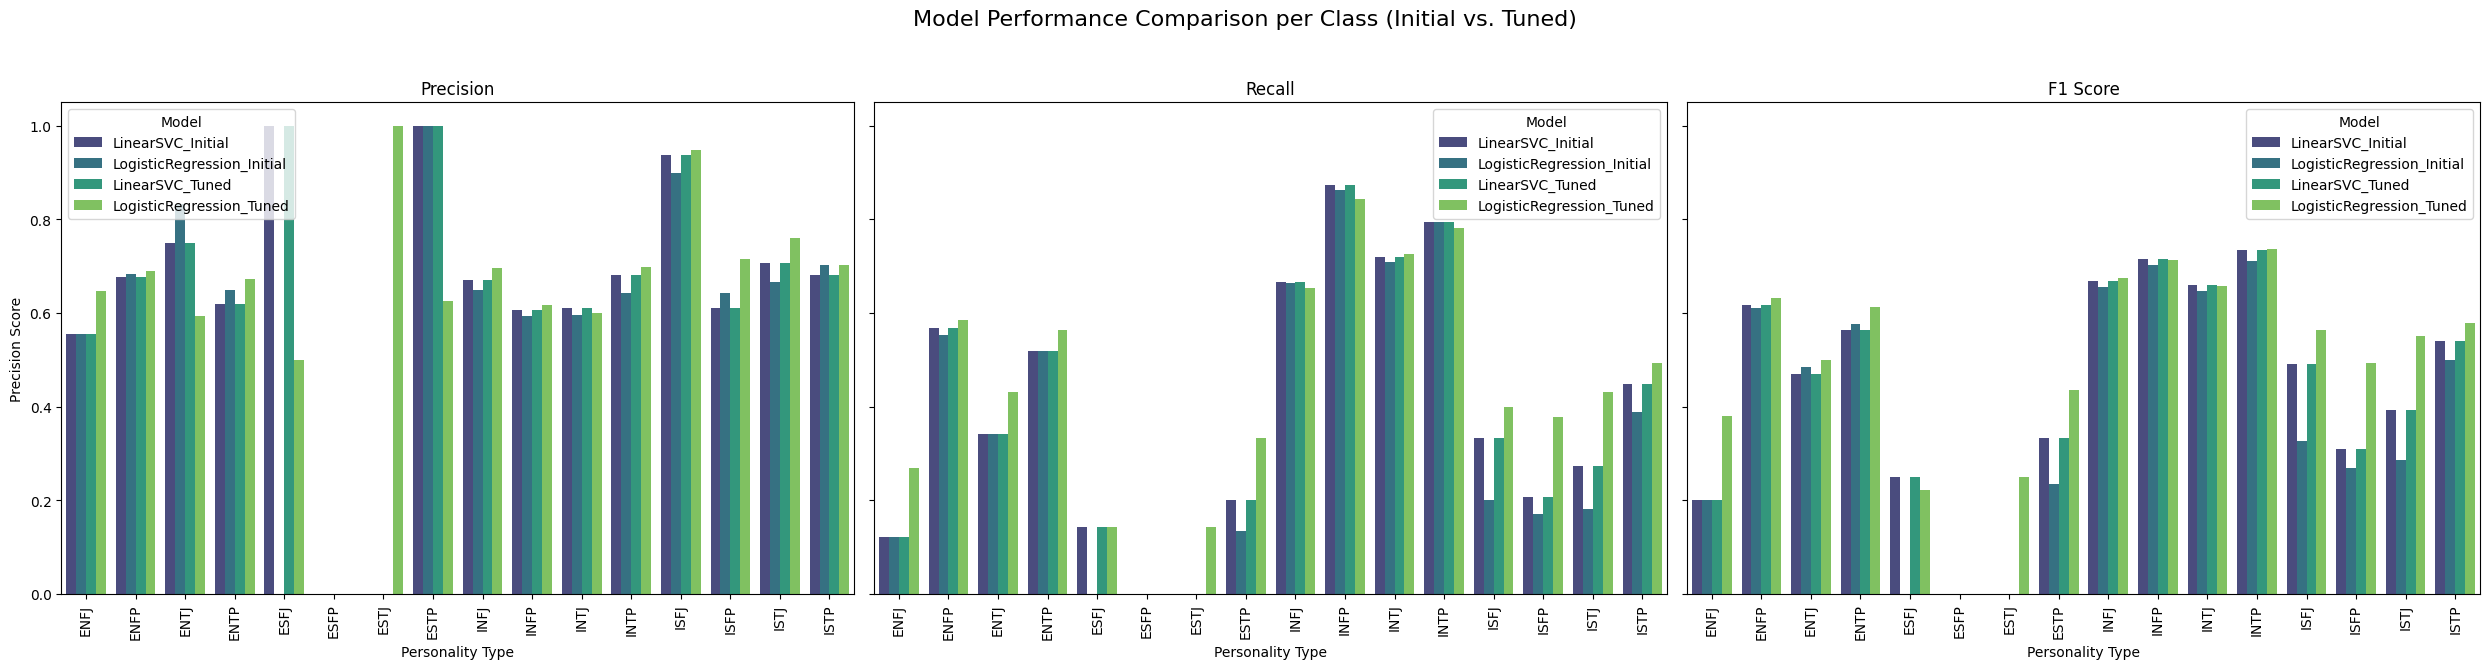

In [58]:
df_svm_tuned = pd.DataFrame(report_svc_tuned).transpose()
df_lr_tuned = pd.DataFrame(report_lr_tuned).transpose()

df_svm_tuned_plot = df_svm_tuned.drop(index=['accuracy', 'macro avg', 'weighted avg'])
df_lr_tuned_plot = df_lr_tuned.drop(index=['accuracy', 'macro avg', 'weighted avg'])

df_svm_tuned_plot['model'] = 'LinearSVC_Tuned'
df_lr_tuned_plot['model'] = 'LogisticRegression_Tuned'

# Include the initial models for comparison
df_svm_plot['model'] = 'LinearSVC_Initial'
df_lr_plot['model'] = 'LogisticRegression_Initial'

combined_df_all = pd.concat([df_svm_plot, df_lr_plot, df_svm_tuned_plot, df_lr_tuned_plot])
combined_df_all = combined_df_all.reset_index().rename(columns={'index': 'class'})

melted_df_all = combined_df_all.melt(id_vars=['class', 'model'], value_vars=['precision', 'recall', 'f1-score'], var_name='metric', value_name='score')

metrics_to_plot = ['precision', 'recall', 'f1-score']
fig, axes = plt.subplots(1, 3, figsize=(25, 7), sharey=True)
fig.suptitle('Model Performance Comparison per Class (Initial vs. Tuned)', fontsize=16)

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='class', y='score', hue='model', data=melted_df_all[melted_df_all['metric'] == metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric.replace("-", " ").title()}')
    axes[i].set_xlabel('Personality Type')
    axes[i].set_ylabel(f'{metric.title()} Score')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].legend(title='Model')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()